In [6]:
import pandas as pd
import numpy as np

def merge_ip_to_country_direct(fraud_df, ip_df):
    """
    Directly maps numeric IP fields to countries using highly optimized 
    binary range search arrays.
    """
    fraud_df = fraud_df.copy()
    
    # Clean up float scientific notations into standard clean integers
    # Justification: IP mapping relies on explicit integer bounds tracking
    fraud_df['ip_int'] = fraud_df['ip_address'].fillna(0).astype(np.int64)
    
    # Sort lookup limits to ensure searchsorted works flawlessly
    ip_df = ip_df.sort_values(by='lower_bound_ip_address').reset_index(drop=True)
    
    print("Performing fast range-based country lookup...")
    # Map the position index where each numeric fraud IP fits in the lower bounds array
    idx = np.searchsorted(ip_df['lower_bound_ip_address'].values, fraud_df['ip_int'].values) - 1
    idx = np.clip(idx, 0, len(ip_df) - 1)
    
    # Verify boundary integrity: lower_bound <= ip_int <= upper_bound
    valid_mask = (fraud_df['ip_int'].values >= ip_df['lower_bound_ip_address'].values[idx]) & \
                 (fraud_df['ip_int'].values <= ip_df['upper_bound_ip_address'].values[idx])
    
    # Assign verified country text; fall back to 'Unknown' for out-of-bounds IPs
    fraud_df['country'] = np.where(valid_mask, ip_df['country'].values[idx], 'Unknown')
    
    return fraud_df

# --- Execution Workflow ---
print("Loading raw files...")
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_data = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Clean base records and format timestamps
fraud_data = fraud_data.drop_duplicates()
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Run the direct numerical mapping engine
fraud_enriched = merge_ip_to_country_direct(fraud_data, ip_data)

print(f"\nEnrichment complete! Total processed rows: {len(fraud_enriched)}")
print("Let's look at a preview of our new country column columns:")
print(fraud_enriched[['user_id', 'ip_address', 'ip_int', 'country']].head())

Loading raw files...
Performing fast range-based country lookup...

Enrichment complete! Total processed rows: 151112
Let's look at a preview of our new country column columns:
   user_id    ip_address      ip_int        country
0    22058  7.327584e+08   732758368          Japan
1   333320  3.503114e+08   350311387  United States
2     1359  2.621474e+09  2621473820  United States
3   150084  3.840542e+09  3840542443        Unknown
4   221365  4.155831e+08   415583117  United States


In [7]:
# --- Feature Engineering Pipeline ---
print("Engineering behavioral and temporal features...")

# 1. Calculate time_since_signup (Duration between signup and purchase in seconds)
# Justification: Bots purchase instantly (close to 0 seconds); real users take time browsing.
fraud_enriched['time_since_signup'] = (fraud_enriched['purchase_time'] - fraud_enriched['signup_time']).dt.total_seconds()

# 2. Extract temporal markers
# Justification: Fraud spikes during odd midnight hours or specific days of the week.
fraud_enriched['hour_of_day'] = fraud_enriched['purchase_time'].dt.hour
fraud_enriched['day_of_week'] = fraud_enriched['purchase_time'].dt.dayofweek

# 3. Transaction Frequency / Velocity
# Justification: Multiple unique users sharing one device or IP indicates a hijacked hardware attack.
fraud_enriched['user_device_count'] = fraud_enriched.groupby('device_id')['user_id'].transform('count')
fraud_enriched['user_ip_count'] = fraud_enriched.groupby('ip_address')['user_id'].transform('count')

print("Feature engineering complete!")
print(fraud_enriched[['time_since_signup', 'hour_of_day', 'day_of_week', 'user_device_count', 'user_ip_count']].head())

Engineering behavioral and temporal features...
Feature engineering complete!
   time_since_signup  hour_of_day  day_of_week  user_device_count  \
0          4506682.0            2            5                  1   
1            17944.0            1            0                  1   
2                1.0           18            3                 12   
3           492085.0           13            0                  1   
4          4361461.0           18            2                  1   

   user_ip_count  
0              1  
1              1  
2             12  
3              1  
4              1  


--- Class Distribution Baseline ---
Legitimate Transactions (Class 0): 136961 (90.64%)
Fraudulent Transactions (Class 1): 14151 (9.36%)


C:\Users\Rio\AppData\Local\Temp\ipykernel_16416\4166055086.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=fraud_enriched, palette='viridis')


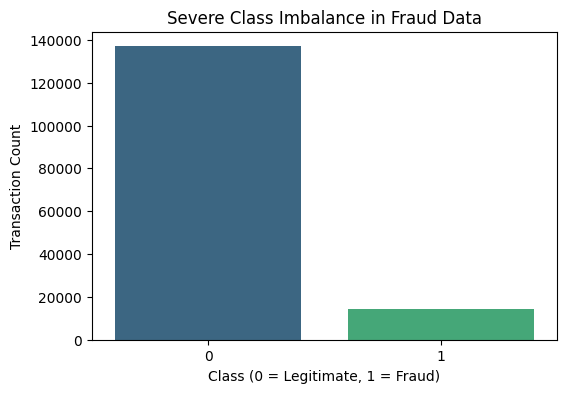


--- Top 10 Countries by Fraud Volume ---
country
United States        5551
Unknown              1883
China                1043
Japan                 715
United Kingdom        477
Korea Republic of     380
Canada                348
France                300
Brazil                270
Germany               262
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Quantify Class Imbalance
class_counts = fraud_enriched['class'].value_counts()
class_pct = fraud_enriched['class'].value_counts(normalize=True) * 100

print("--- Class Distribution Baseline ---")
print(f"Legitimate Transactions (Class 0): {class_counts[0]} ({class_pct[0]:.2f}%)")
print(f"Fraudulent Transactions (Class 1): {class_counts[1]} ({class_pct[1]:.2f}%)")

# 2. Visualize the massive class skew
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=fraud_enriched, palette='viridis')
plt.title('Severe Class Imbalance in Fraud Data')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Count')
plt.show()

# 3. Analyze Top Fraud Patterns by Country
print("\n--- Top 10 Countries by Fraud Volume ---")
fraud_by_country = fraud_enriched[fraud_enriched['class'] == 1]['country'].value_counts().head(10)
print(fraud_by_country)